Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print(" Libraries imported")

 Libraries imported


Load Dataset

In [2]:
df = pd.read_csv('../OnlineNewsPopularity/OnlineNewsPopularity.csv')


df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Shape: (39644, 61)
Rows: 39,644 | Columns: 61


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


Basic Info

In [3]:
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
print(f"\nShape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
print(f"\nColumn Names:\n{list(df.columns)}")

DATASET INFO

Shape: (39644, 61)
Memory Usage: 22.48 MB

Data Types:
float64    59
object      1
int64       1
Name: count, dtype: int64

Column Names:
['url', 'timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_s

Missing Values

Missing Values Analysis:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
 No missing values found!


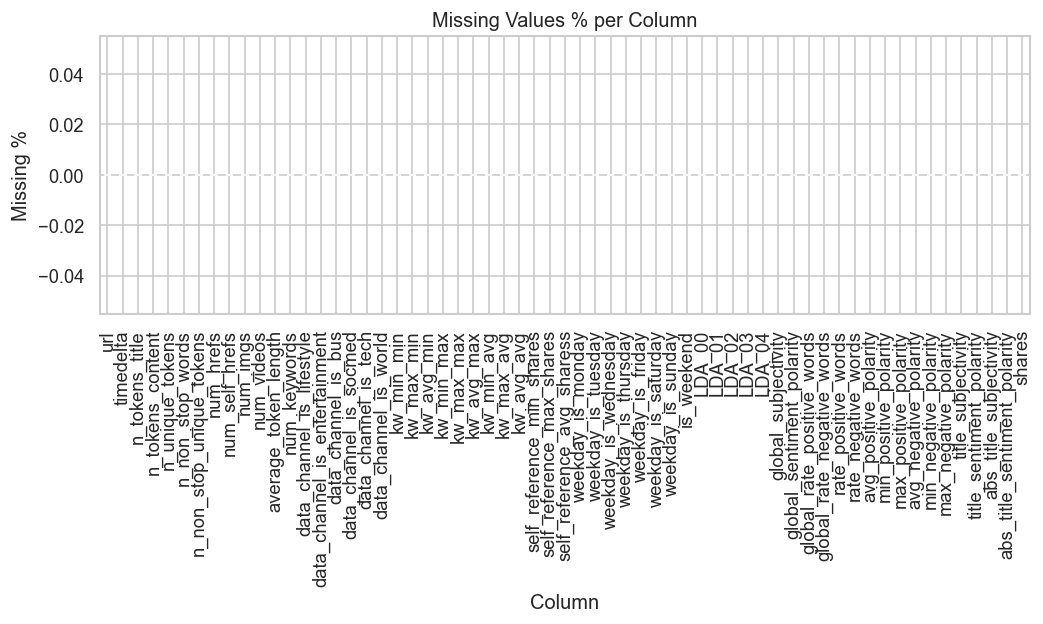

In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print(" No missing values found!")

# Plot
plt.figure(figsize=(10, 3))
missing_pct.plot(kind='bar')
plt.title('Missing Values % per Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.tight_layout()
plt.savefig('figures/eda01_missing_values.png', bbox_inches='tight')
plt.show()

Duplicates

In [5]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

if dupes == 0:
    print(" No duplicate rows found!")
else:
    df = df.drop_duplicates()
    print(f" Removed {dupes} duplicates. New shape: {df.shape}")

Duplicate rows: 0
 No duplicate rows found!


Statistical Summary

In [6]:
print("Numerical Features Summary:")
df.describe().T.round(3)

Numerical Features Summary:


,count,mean,std,min,25%,50%,75%,max
timedelta,39644.0,354.530,214.164,8.000,164.000,339.000,542.000,731.000
n_tokens_title,39644.0,10.399,2.114,2.000,9.000,10.000,12.000,23.000
n_tokens_content,39644.0,546.515,471.108,0.000,246.000,409.000,716.000,8474.000
n_unique_tokens,39644.0,0.548,3.521,0.000,0.471,0.539,0.609,701.000
n_non_stop_words,39644.0,0.996,5.231,0.000,1.000,1.000,1.000,1042.000
n_non_stop_unique_tokens,39644.0,0.689,3.265,0.000,0.626,0.690,0.755,650.000
num_hrefs,39644.0,10.884,11.332,0.000,4.000,8.000,14.000,304.000
num_self_hrefs,39644.0,3.294,3.855,0.000,1.000,3.000,4.000,116.000
num_imgs,39644.0,4.544,8.309,0.000,1.000,1.000,4.000,128.000
num_videos,39644.0,1.250,4.108,0.000,0.000,0.000,1.000,91.000


Target Variable Analysis (shares)

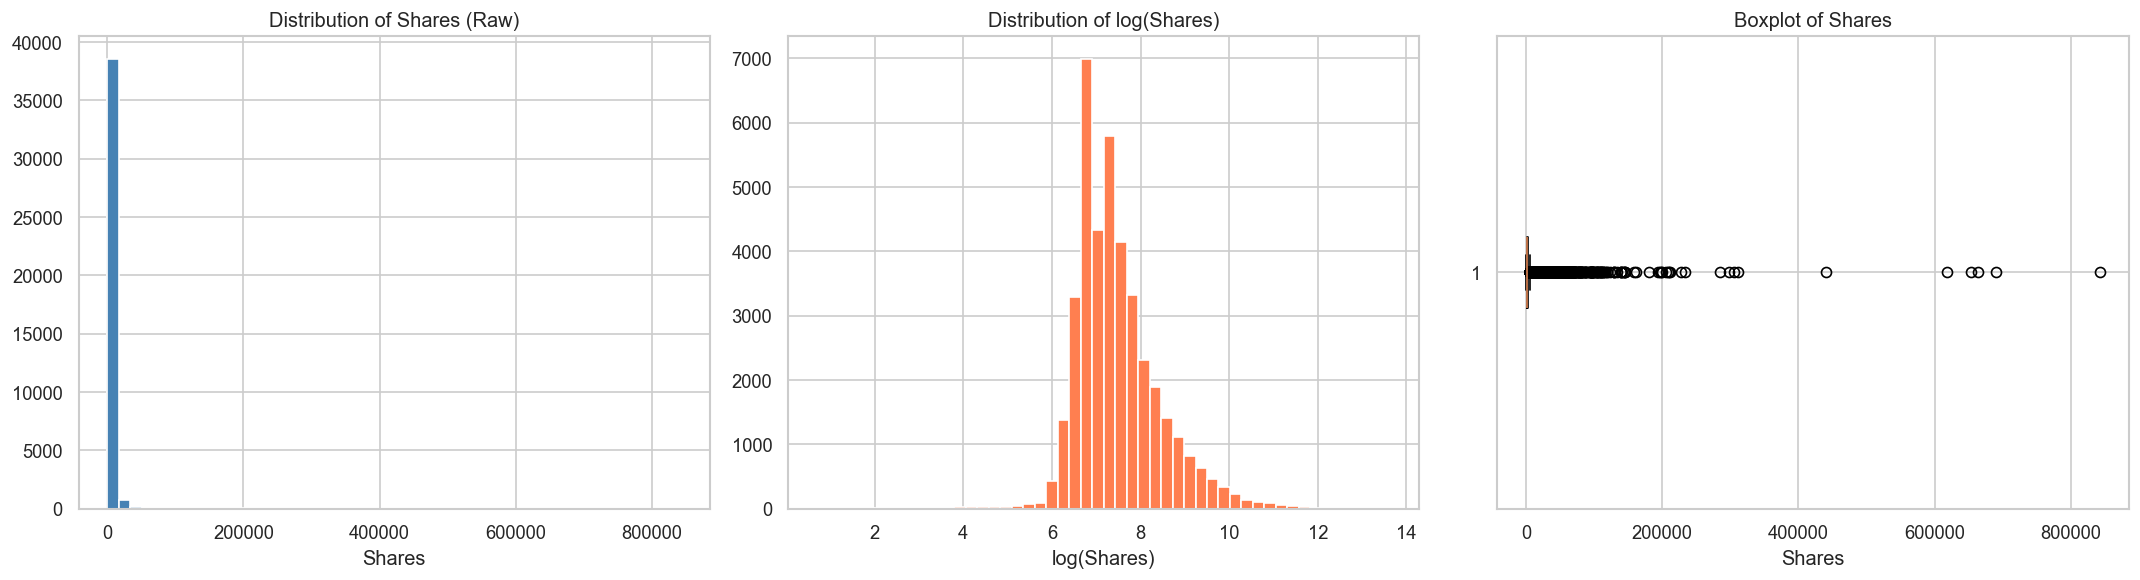

Shares Stats:
  Mean:     3,395
  Median:   1,400
  Std:      11,627
  Max:      843,300
  Skewness: 33.96
  log_shares skewness: 1.03


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].hist(df['shares'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Shares (Raw)')
axes[0].set_xlabel('Shares')


log_shares = np.log1p(df['shares'])
axes[1].hist(log_shares, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of log(Shares)')
axes[1].set_xlabel('log(Shares)')

axes[2].boxplot(df['shares'], vert=False)
axes[2].set_title('Boxplot of Shares')
axes[2].set_xlabel('Shares')

plt.tight_layout()
plt.savefig('figures/eda02_target_distribution.png', bbox_inches='tight')
plt.show()

print(f"Shares Stats:")
print(f"  Mean:     {df['shares'].mean():,.0f}")
print(f"  Median:   {df['shares'].median():,.0f}")
print(f"  Std:      {df['shares'].std():,.0f}")
print(f"  Max:      {df['shares'].max():,.0f}")
print(f"  Skewness: {df['shares'].skew():.2f}")
print(f"  log_shares skewness: {log_shares.skew():.2f}")

Add log_shares + Clean Outliers

In [8]:

ratio_cols = ['n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens']
for col in ratio_cols:
    if col in df.columns:
        df[col] = df[col].clip(0, 1)


clip_cols = [
    'n_tokens_content', 'num_hrefs', 'num_self_hrefs',
    'num_imgs', 'num_videos',
    'kw_max_min', 'kw_avg_min', 'kw_min_max',
    'kw_max_max', 'kw_avg_max', 'kw_max_avg',
    'self_reference_min_shares', 'self_reference_max_shares',
    'self_reference_avg_sharess'
]
for col in clip_cols:
    if col in df.columns:
        lo = df[col].quantile(0.01)
        hi = df[col].quantile(0.99)
        df[col] = df[col].clip(lo, hi)


hi_shares = df['shares'].quantile(0.99)
df = df[df['shares'] <= hi_shares].copy()


df['log_shares'] = np.log1p(df['shares'])

print(f"✅ Cleaned! Rows: {df.shape[0]:,}")
print(f"Shares max after cleaning: {df['shares'].max():,}")
print(f"log_shares skewness: {df['log_shares'].skew():.4f}")

✅ Cleaned! Rows: 39,247
Shares max after cleaning: 31,600
log_shares skewness: 0.6857


Numerical Features Distributions

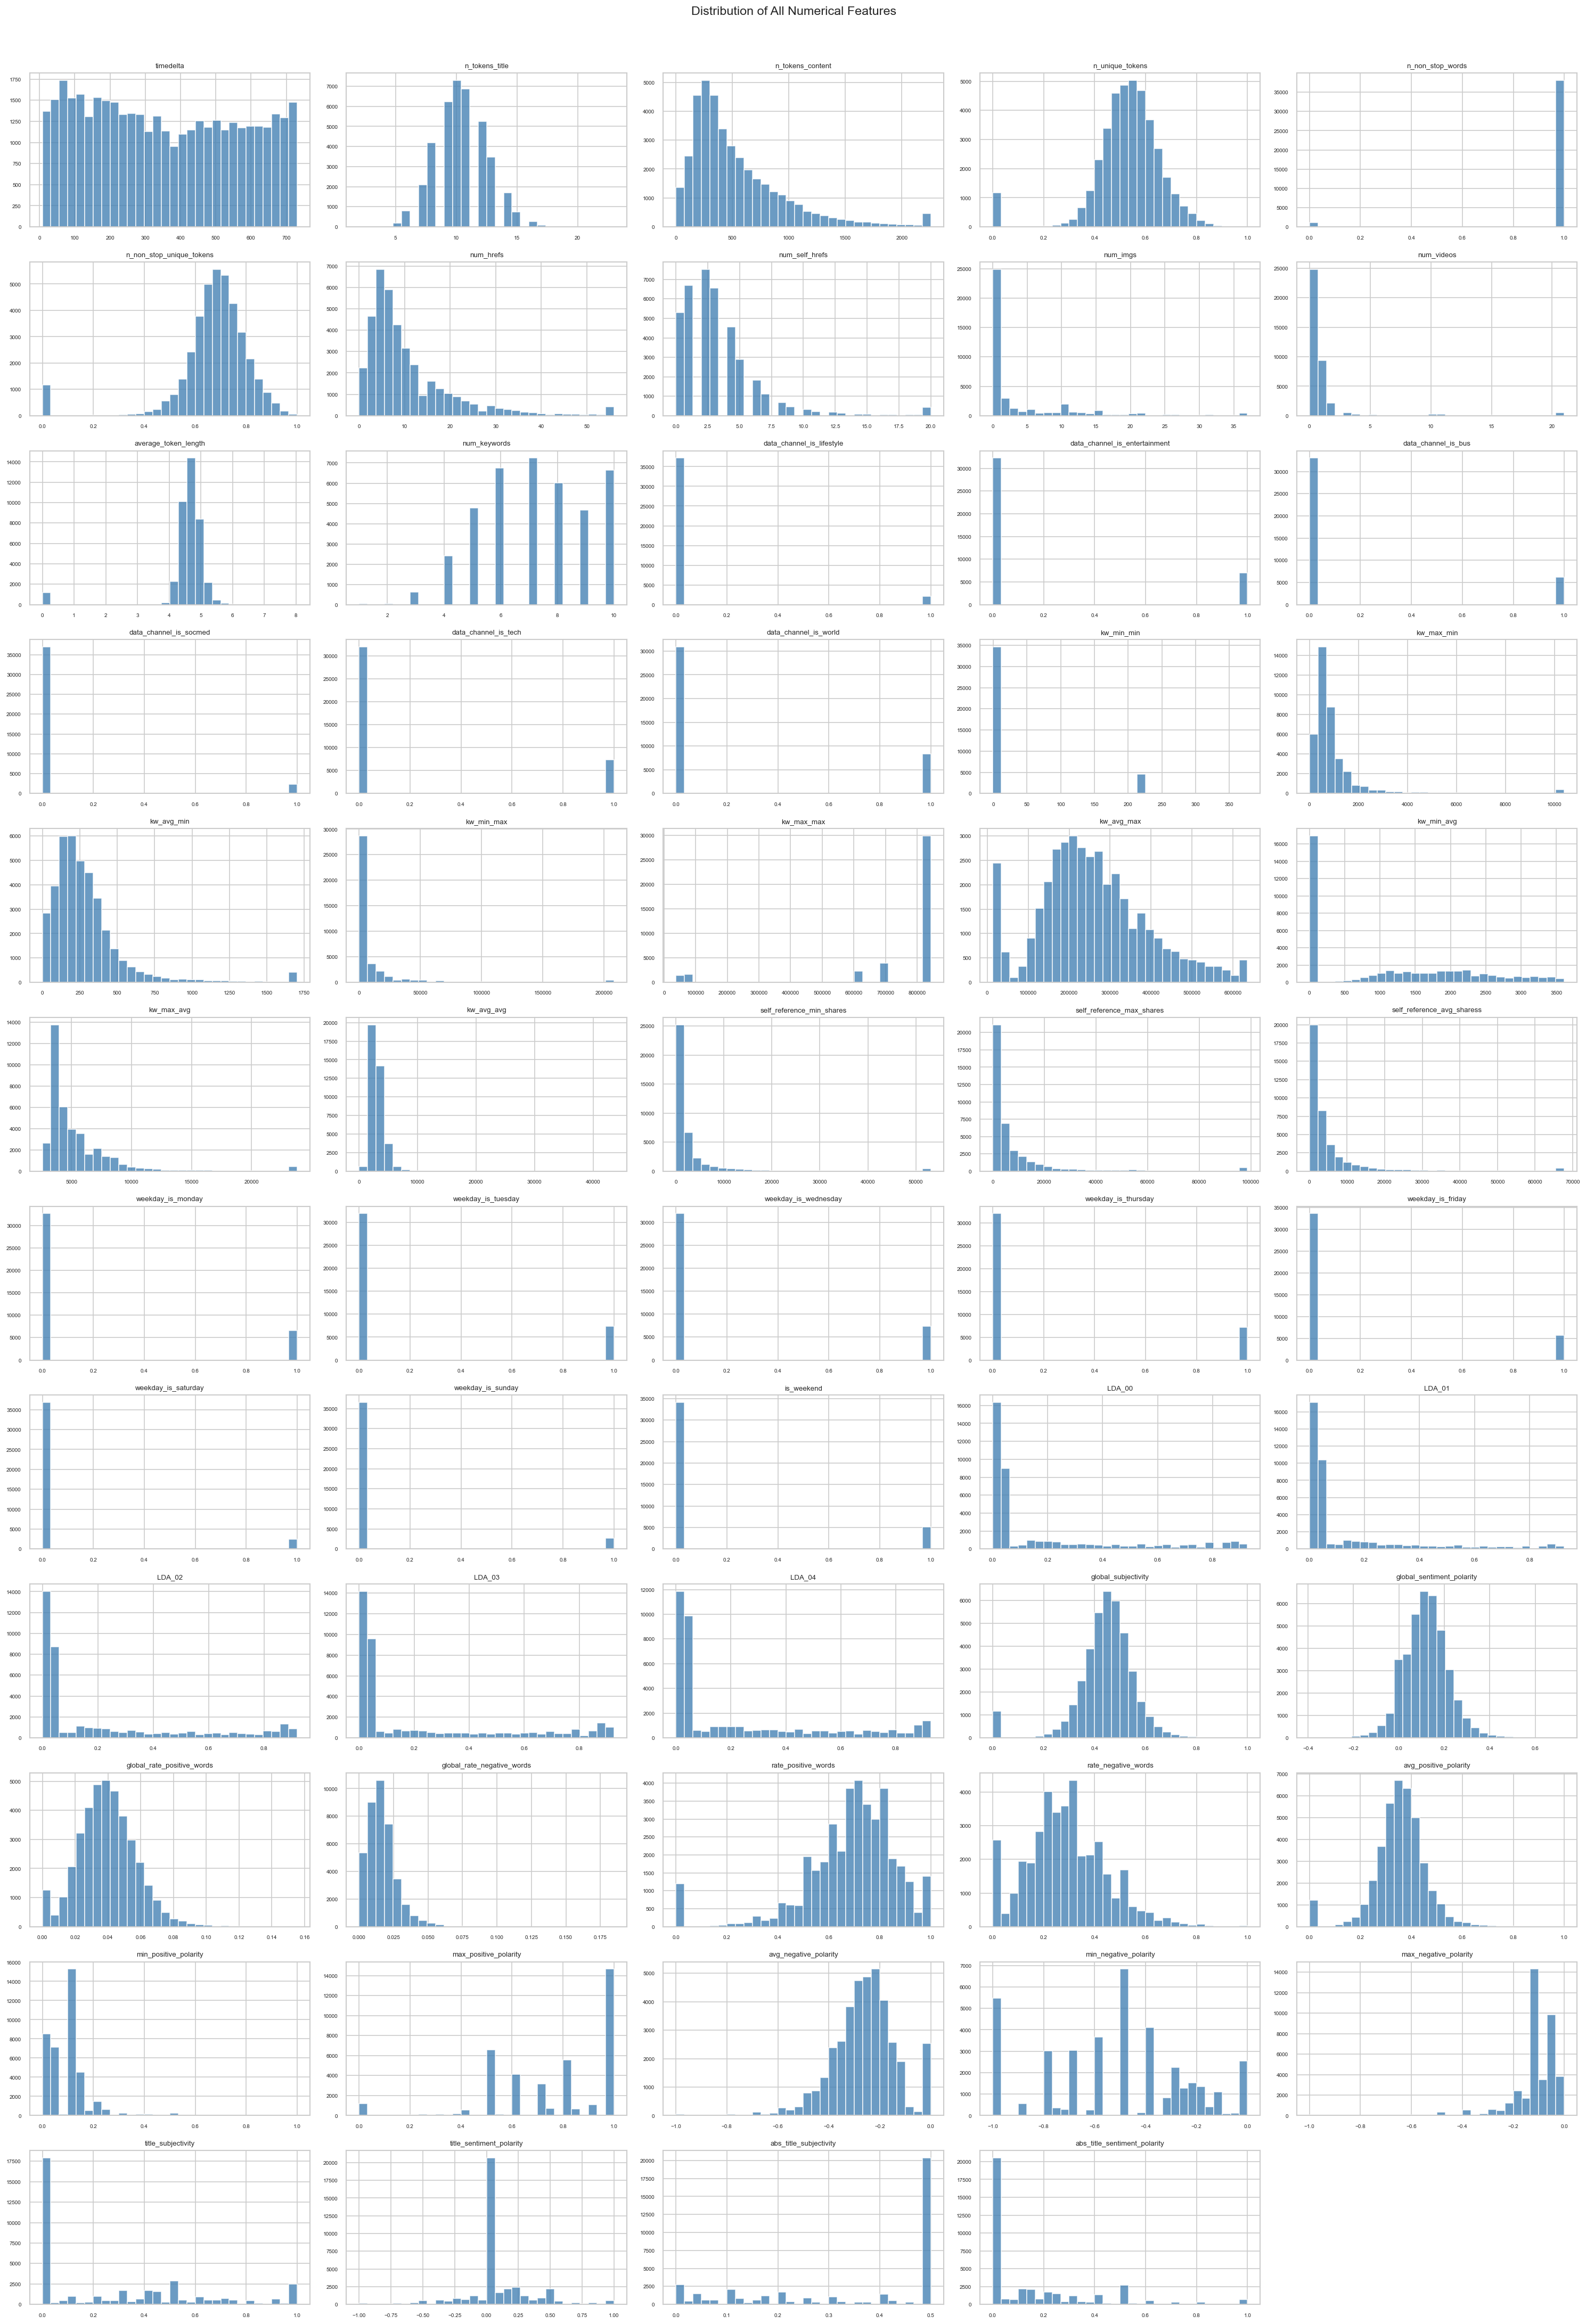

In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['shares', 'log_shares']]


n = len(num_cols)
cols = 5
rows = (n // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(25, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/eda03_all_distributions.png', bbox_inches='tight')
plt.show()

Skewness Analysis

Top 10 Most Skewed Features:
kw_avg_avg                    5.791652
kw_min_max                    4.967818
self_reference_min_shares     4.947587
kw_max_min                    4.711653
num_videos                    4.545769
self_reference_avg_sharess    4.191801
data_channel_is_lifestyle     3.992998
self_reference_max_shares     3.851354
data_channel_is_socmed        3.751755
weekday_is_saturday           3.639307
dtype: float64

Bottom 5 (Negative Skew):
n_non_stop_unique_tokens   -2.410010
kw_max_max                 -2.635329
max_negative_polarity      -3.467609
average_token_length       -4.583331
n_non_stop_words           -5.542685
dtype: float64


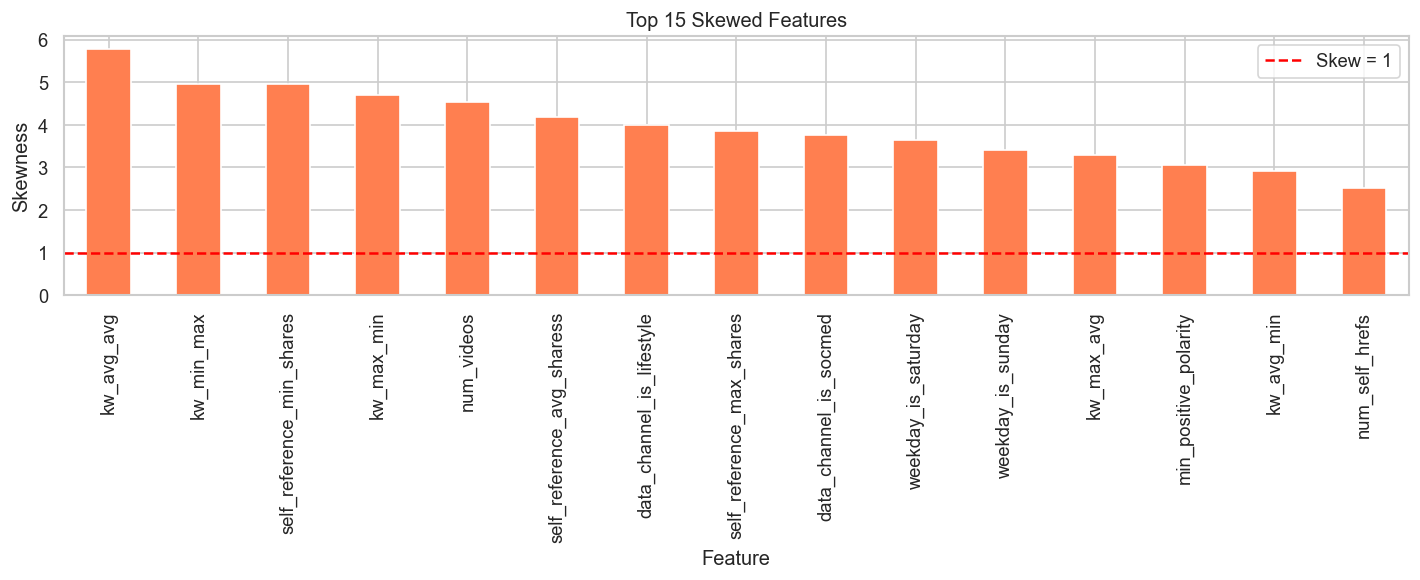

In [10]:
skew_vals = df[num_cols].skew().sort_values(ascending=False)

print("Top 10 Most Skewed Features:")
print(skew_vals.head(10))
print("\nBottom 5 (Negative Skew):")
print(skew_vals.tail(5))

# Plot
plt.figure(figsize=(12, 5))
skew_vals.head(15).plot(kind='bar', color='coral', edgecolor='white')
plt.title('Top 15 Skewed Features')
plt.xlabel('Feature')
plt.ylabel('Skewness')
plt.axhline(y=1, color='red', linestyle='--', label='Skew = 1')
plt.legend()
plt.tight_layout()
plt.savefig('figures/eda04_skewness.png', bbox_inches='tight')
plt.show()

Outlier Detection (IQR)

Top 15 Features with Most Outliers:
kw_max_max                       9379
data_channel_is_world            8385
title_sentiment_polarity         7821
num_imgs                         7560
weekday_is_wednesday             7364
weekday_is_tuesday               7321
data_channel_is_tech             7314
weekday_is_thursday              7201
data_channel_is_entertainment    6988
weekday_is_monday                6583
data_channel_is_bus              6215
LDA_01                           5776
weekday_is_friday                5640
LDA_00                           5240
is_weekend                       5138
dtype: int64


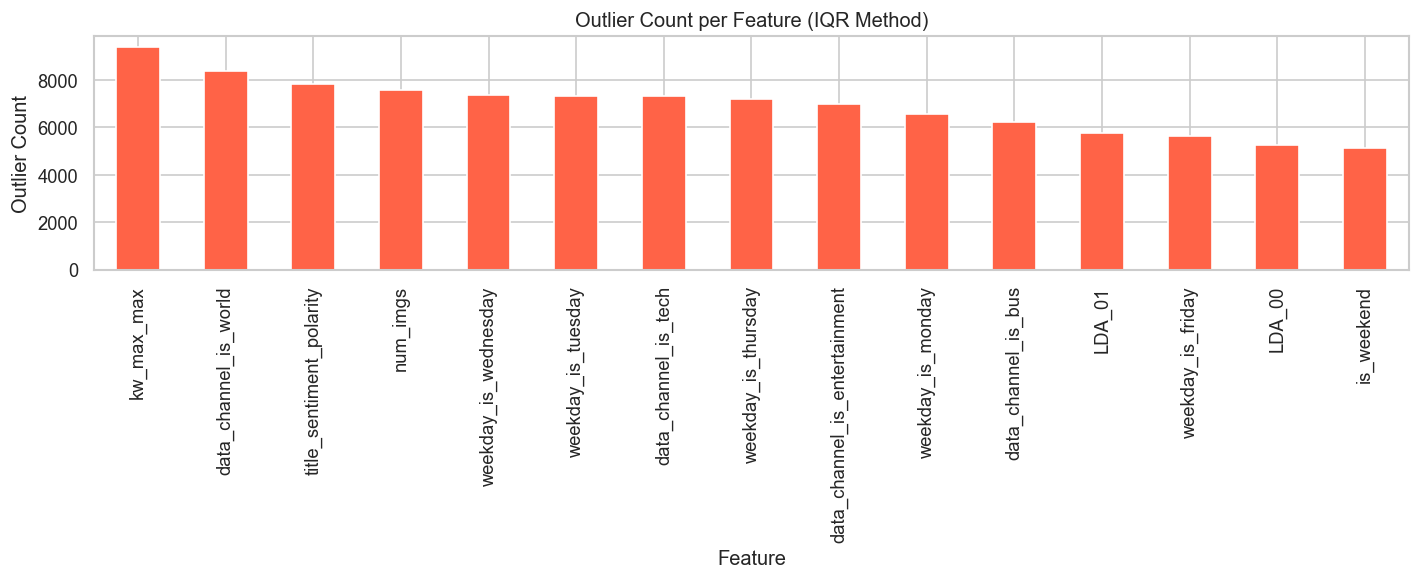

In [11]:
outlier_counts = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    outlier_counts[col] = outliers

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print("Top 15 Features with Most Outliers:")
print(outlier_series.head(15))

# Plot
plt.figure(figsize=(12, 5))
outlier_series.head(15).plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Outlier Count per Feature (IQR Method)')
plt.xlabel('Feature')
plt.ylabel('Outlier Count')
plt.tight_layout()
plt.savefig('figures/eda05_outliers.png', bbox_inches='tight')
plt.show()

Boxplots for Key Features

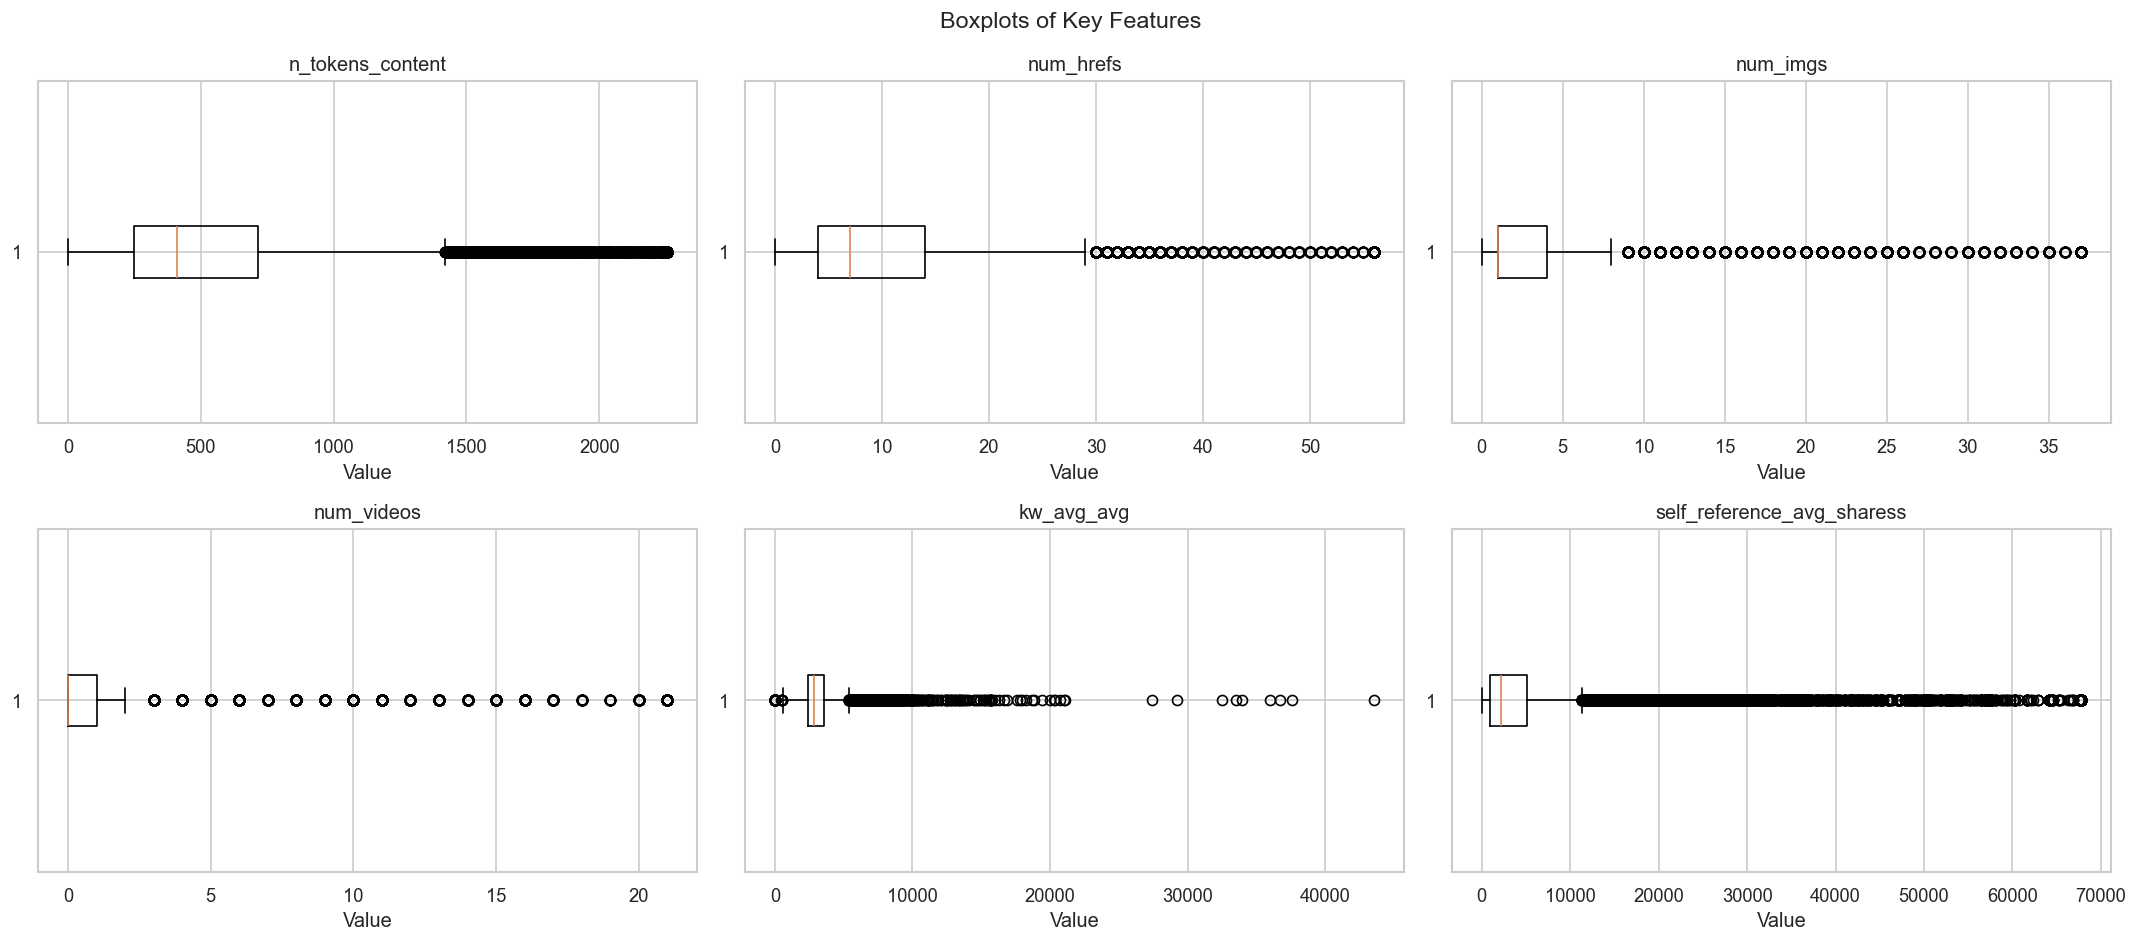

In [12]:
key_cols = [
    'n_tokens_content', 'num_hrefs', 'num_imgs',
    'num_videos', 'kw_avg_avg', 'self_reference_avg_sharess'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')

plt.suptitle('Boxplots of Key Features', fontsize=14)
plt.tight_layout()
plt.savefig('figures/eda06_boxplots.png', bbox_inches='tight')
plt.show()

Correlation Heatmap

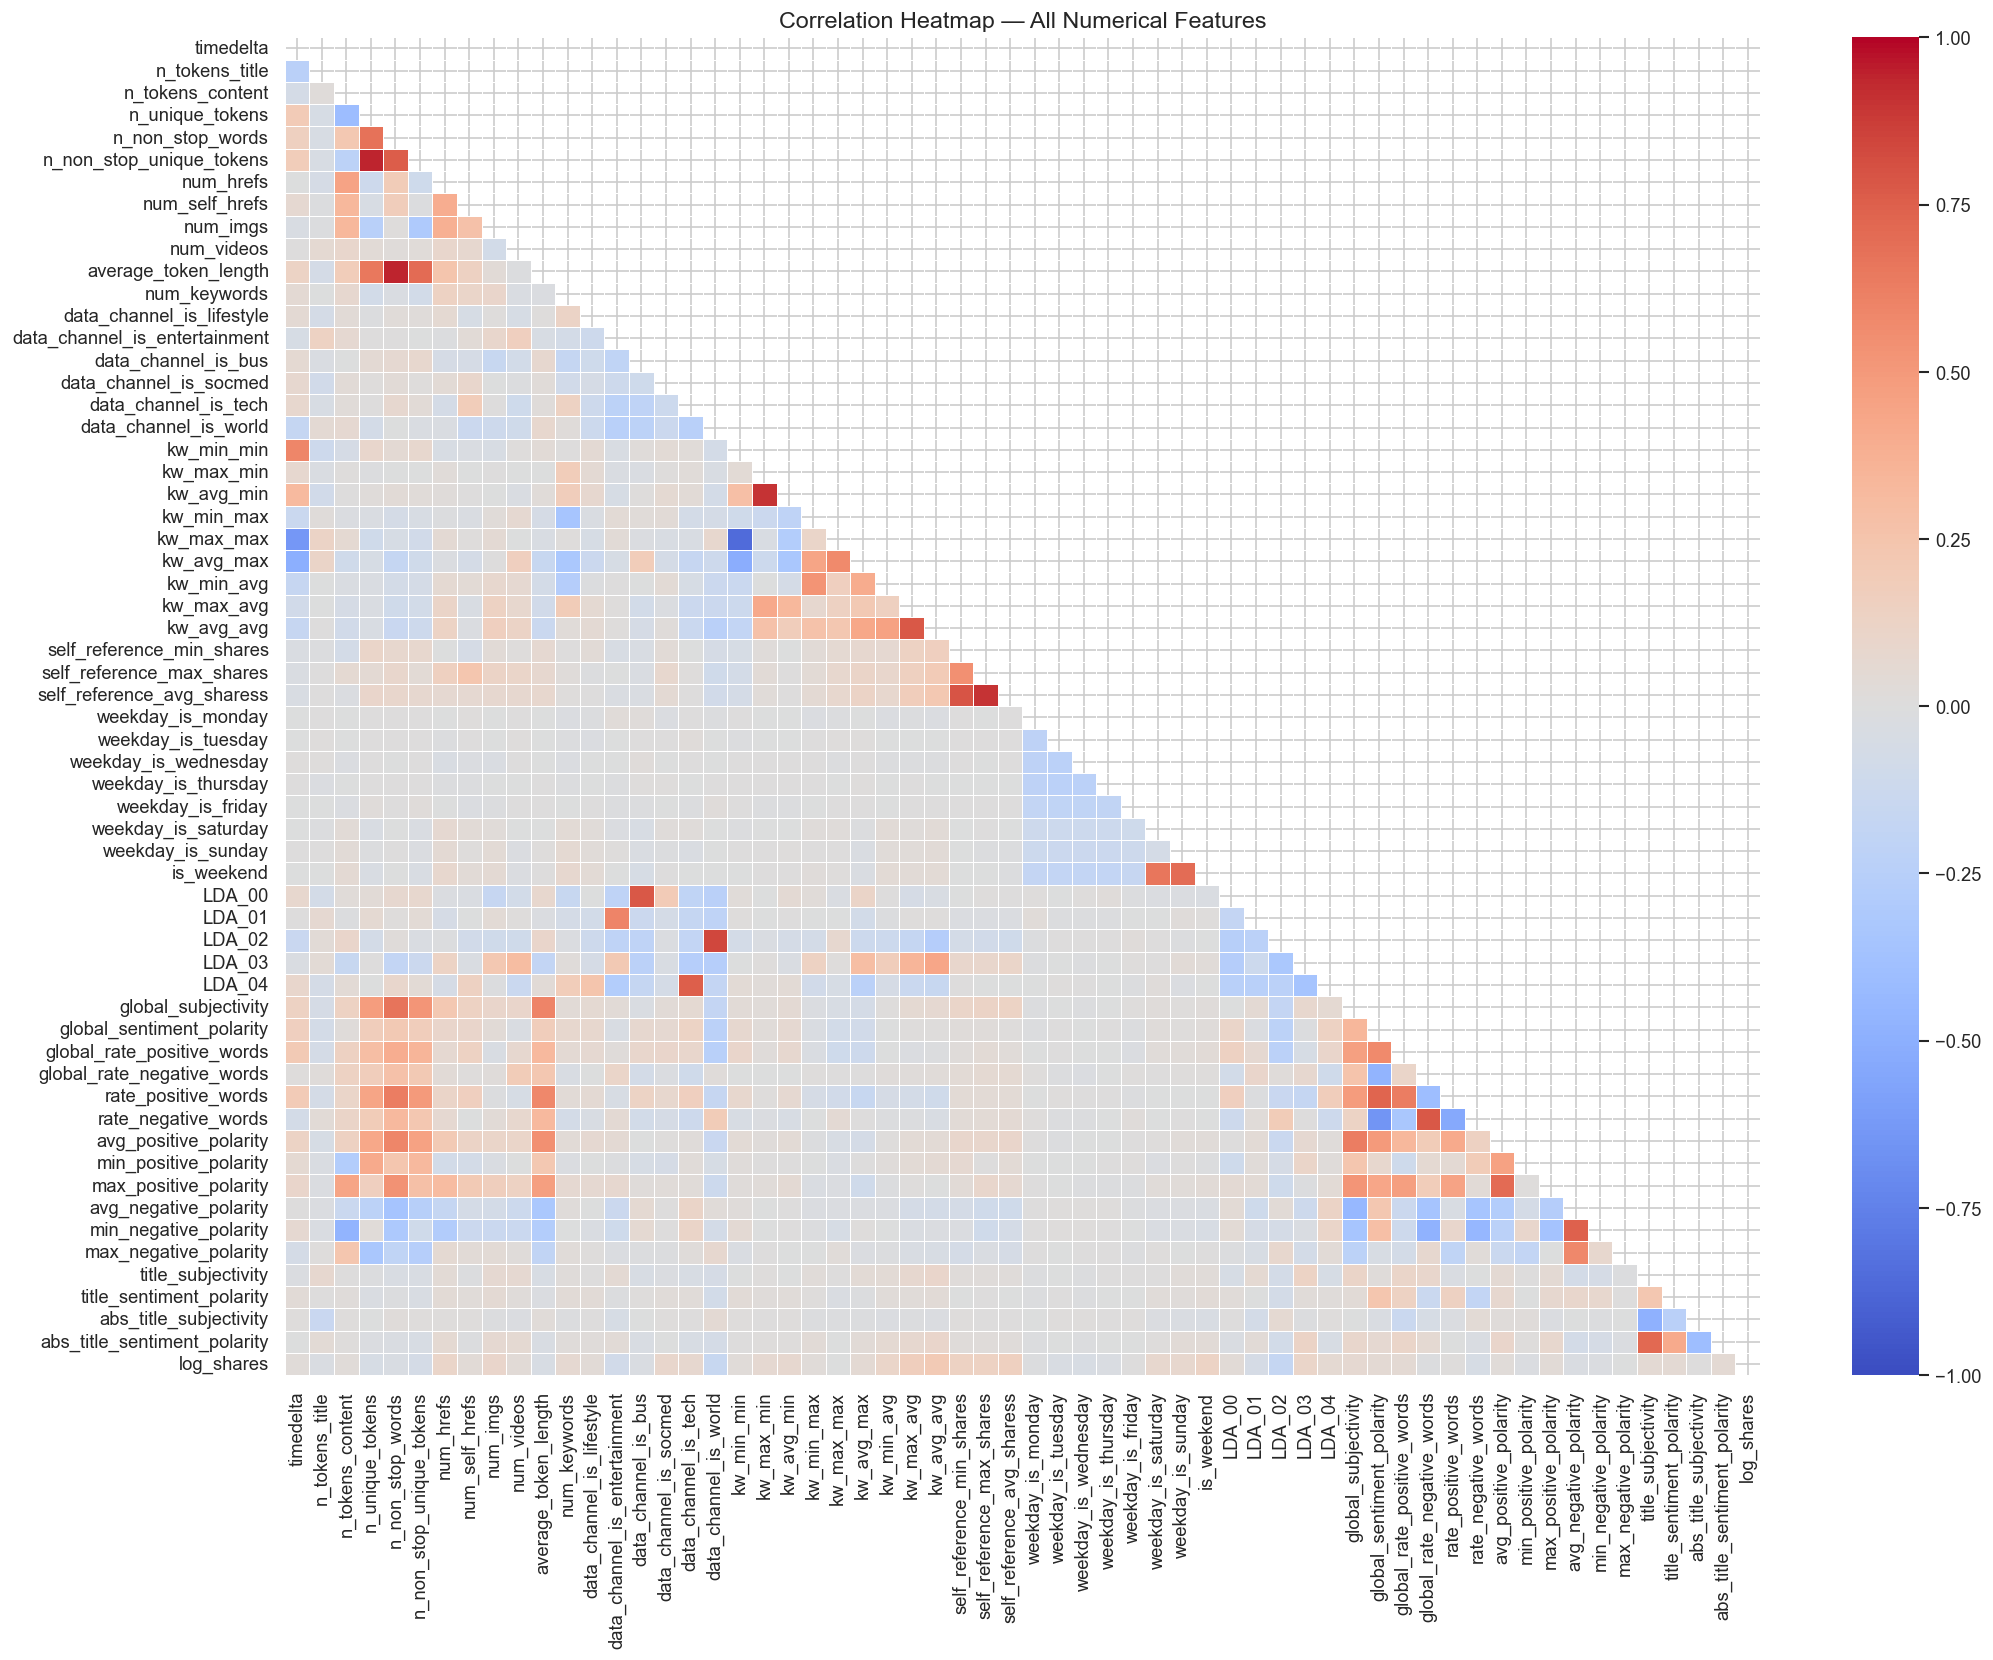

In [13]:

corr_matrix = df[num_cols + ['log_shares']].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='coolwarm',
    center=0, annot=False, linewidths=0.3,
    vmin=-1, vmax=1
)
plt.title('Correlation Heatmap — All Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('figures/eda07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

Top Correlations with log_shares

Top 15 Positively Correlated with log_shares:
kw_avg_avg                    0.209521
kw_max_avg                    0.166127
self_reference_avg_sharess    0.151455
self_reference_min_shares     0.136211
self_reference_max_shares     0.135175
is_weekend                    0.125057
kw_min_avg                    0.109062
LDA_03                        0.106956
num_hrefs                     0.103766
num_imgs                      0.095269
data_channel_is_socmed        0.091859
weekday_is_saturday           0.085414
weekday_is_sunday             0.085218
kw_avg_min                    0.074108
data_channel_is_tech          0.070646
Name: log_shares, dtype: float64

Top 5 Negatively Correlated:
LDA_01                          -0.057657
n_non_stop_unique_tokens        -0.063743
data_channel_is_entertainment   -0.089029
data_channel_is_world           -0.153942
LDA_02                          -0.164659
Name: log_shares, dtype: float64


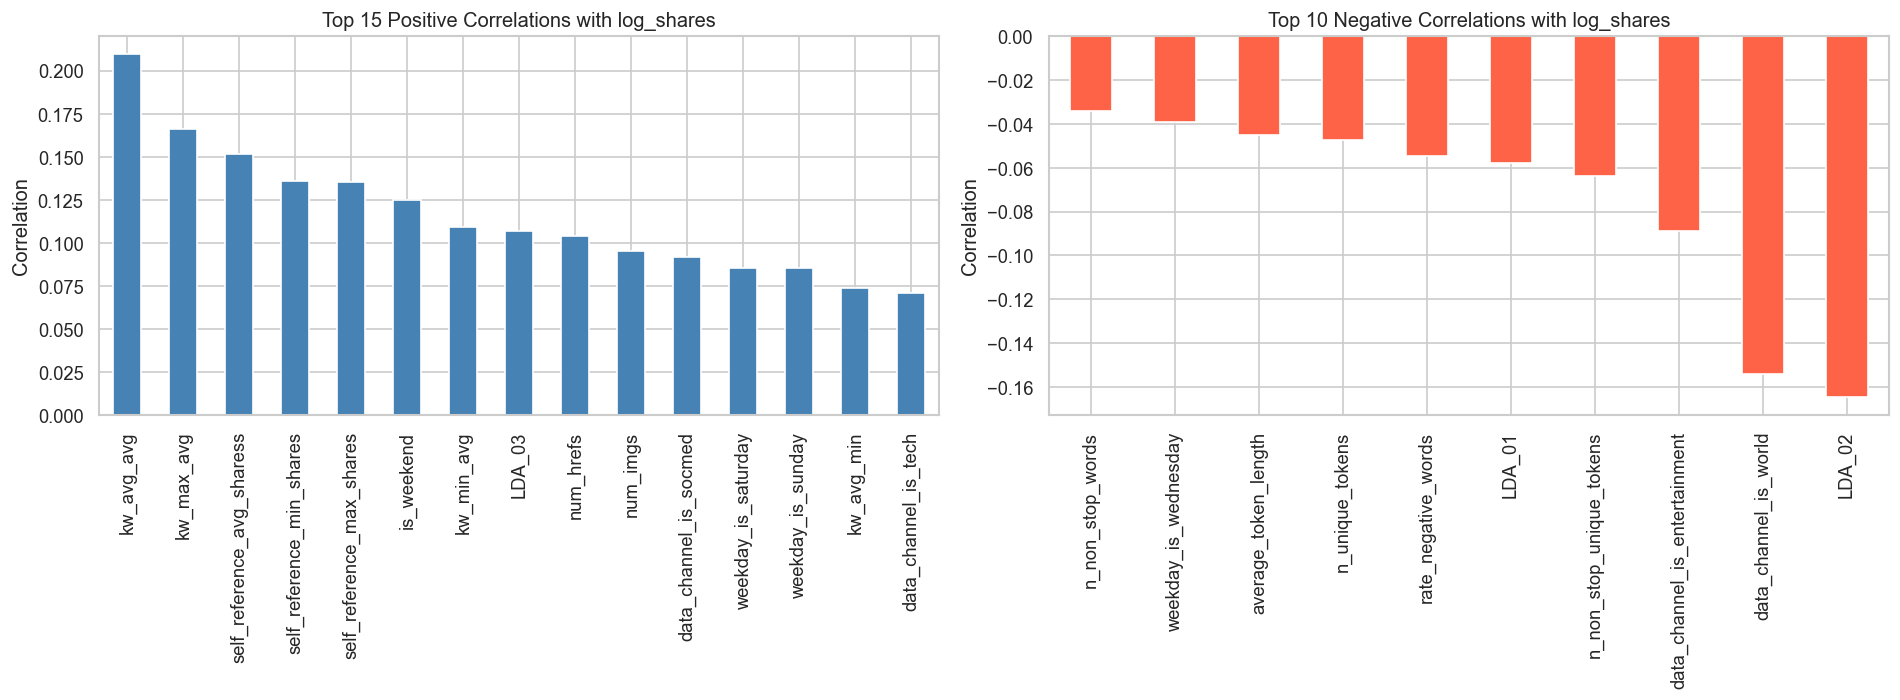

In [14]:
target_corr = corr_matrix['log_shares'].drop('log_shares').sort_values(ascending=False)

print("Top 15 Positively Correlated with log_shares:")
print(target_corr.head(15))
print("\nTop 5 Negatively Correlated:")
print(target_corr.tail(5))


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

target_corr.head(15).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Positive Correlations with log_shares')
axes[0].set_ylabel('Correlation')

target_corr.tail(10).plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Top 10 Negative Correlations with log_shares')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.savefig('figures/eda08_target_correlations.png', bbox_inches='tight')
plt.show()

Day of Week Analysis

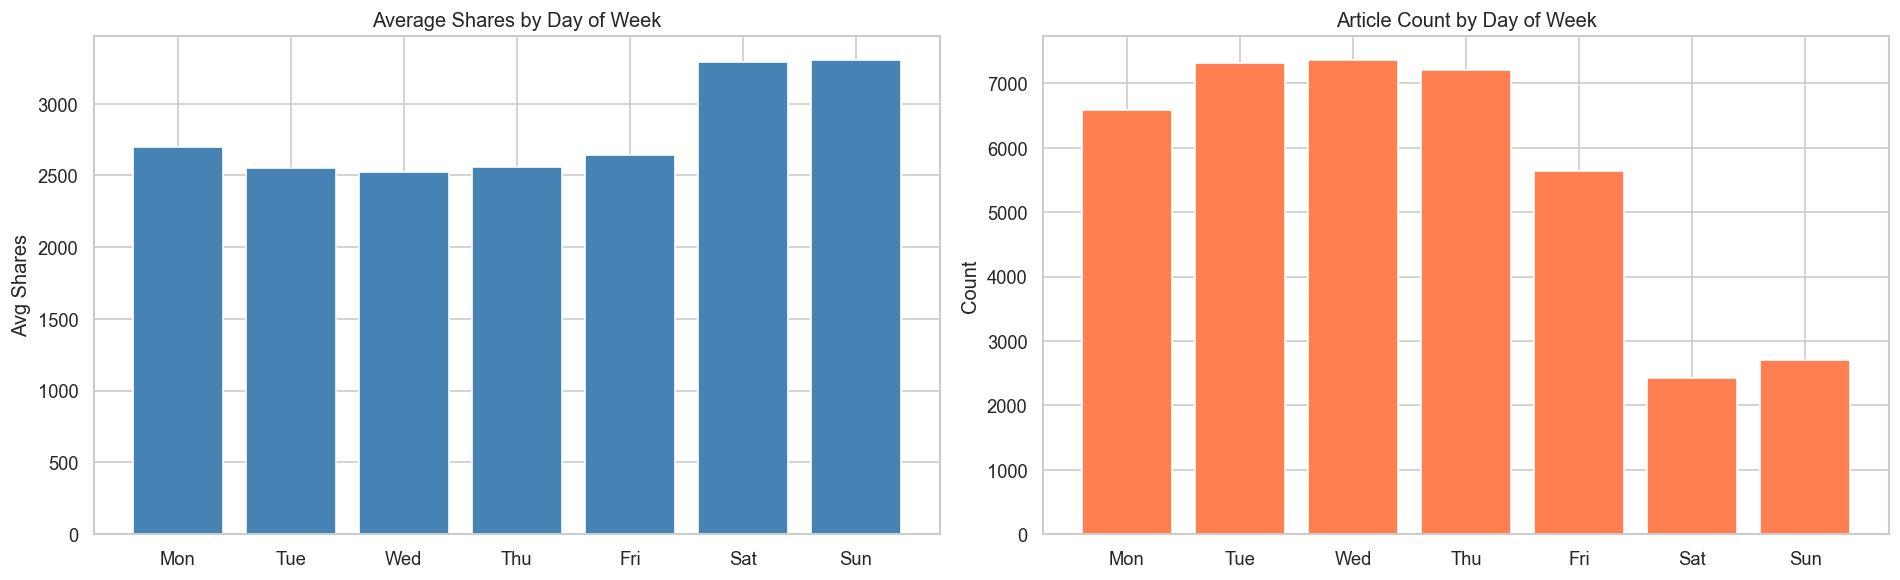

Day of Week — Avg Shares:
  Mon: 2,697
  Tue: 2,554
  Wed: 2,521
  Thu: 2,557
  Fri: 2,645
  Sat: 3,292
  Sun: 3,305


In [15]:
day_cols = [
    'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
    'weekday_is_thursday', 'weekday_is_friday',
    'weekday_is_saturday', 'weekday_is_sunday'
]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

day_avg = []
day_count = []
for col in day_cols:
    mask = df[col] == 1
    day_avg.append(df.loc[mask, 'shares'].mean())
    day_count.append(mask.sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(day_labels, day_avg, color='steelblue', edgecolor='white')
axes[0].set_title('Average Shares by Day of Week')
axes[0].set_ylabel('Avg Shares')

axes[1].bar(day_labels, day_count, color='coral', edgecolor='white')
axes[1].set_title('Article Count by Day of Week')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('figures/eda09_day_of_week.png', bbox_inches='tight')
plt.show()

print("Day of Week — Avg Shares:")
for d, a in zip(day_labels, day_avg):
    print(f"  {d}: {a:,.0f}")

Data Channel / Category Analysis

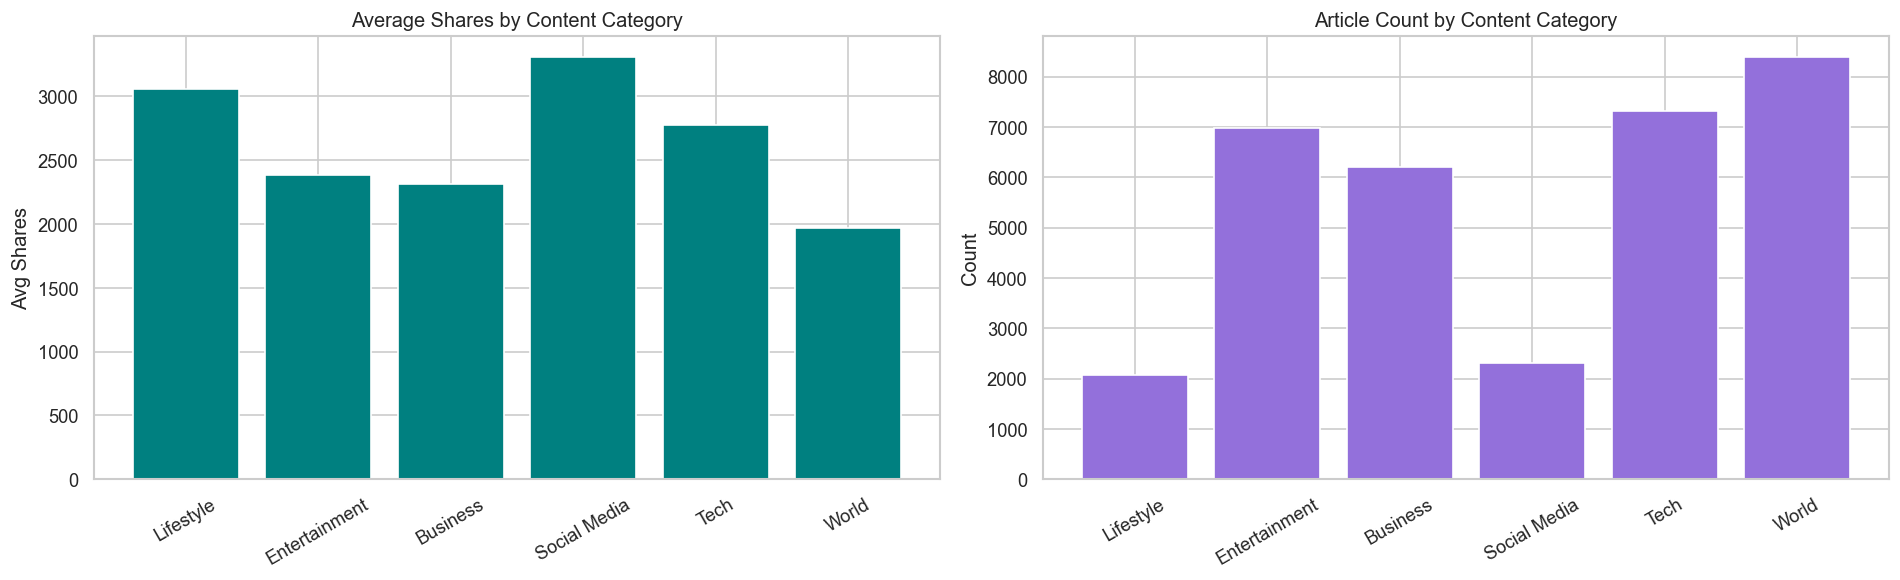

In [16]:
channel_cols = [
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_bus', 'data_channel_is_socmed',
    'data_channel_is_tech', 'data_channel_is_world'
]
channel_labels = ['Lifestyle', 'Entertainment', 'Business', 'Social Media', 'Tech', 'World']

ch_avg = []
ch_count = []
for col in channel_cols:
    if col in df.columns:
        mask = df[col] == 1
        ch_avg.append(df.loc[mask, 'shares'].mean())
        ch_count.append(mask.sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(channel_labels, ch_avg, color='teal', edgecolor='white')
axes[0].set_title('Average Shares by Content Category')
axes[0].set_ylabel('Avg Shares')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(channel_labels, ch_count, color='mediumpurple', edgecolor='white')
axes[1].set_title('Article Count by Content Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('figures/eda10_channels.png', bbox_inches='tight')
plt.show()

Sentiment Analysis

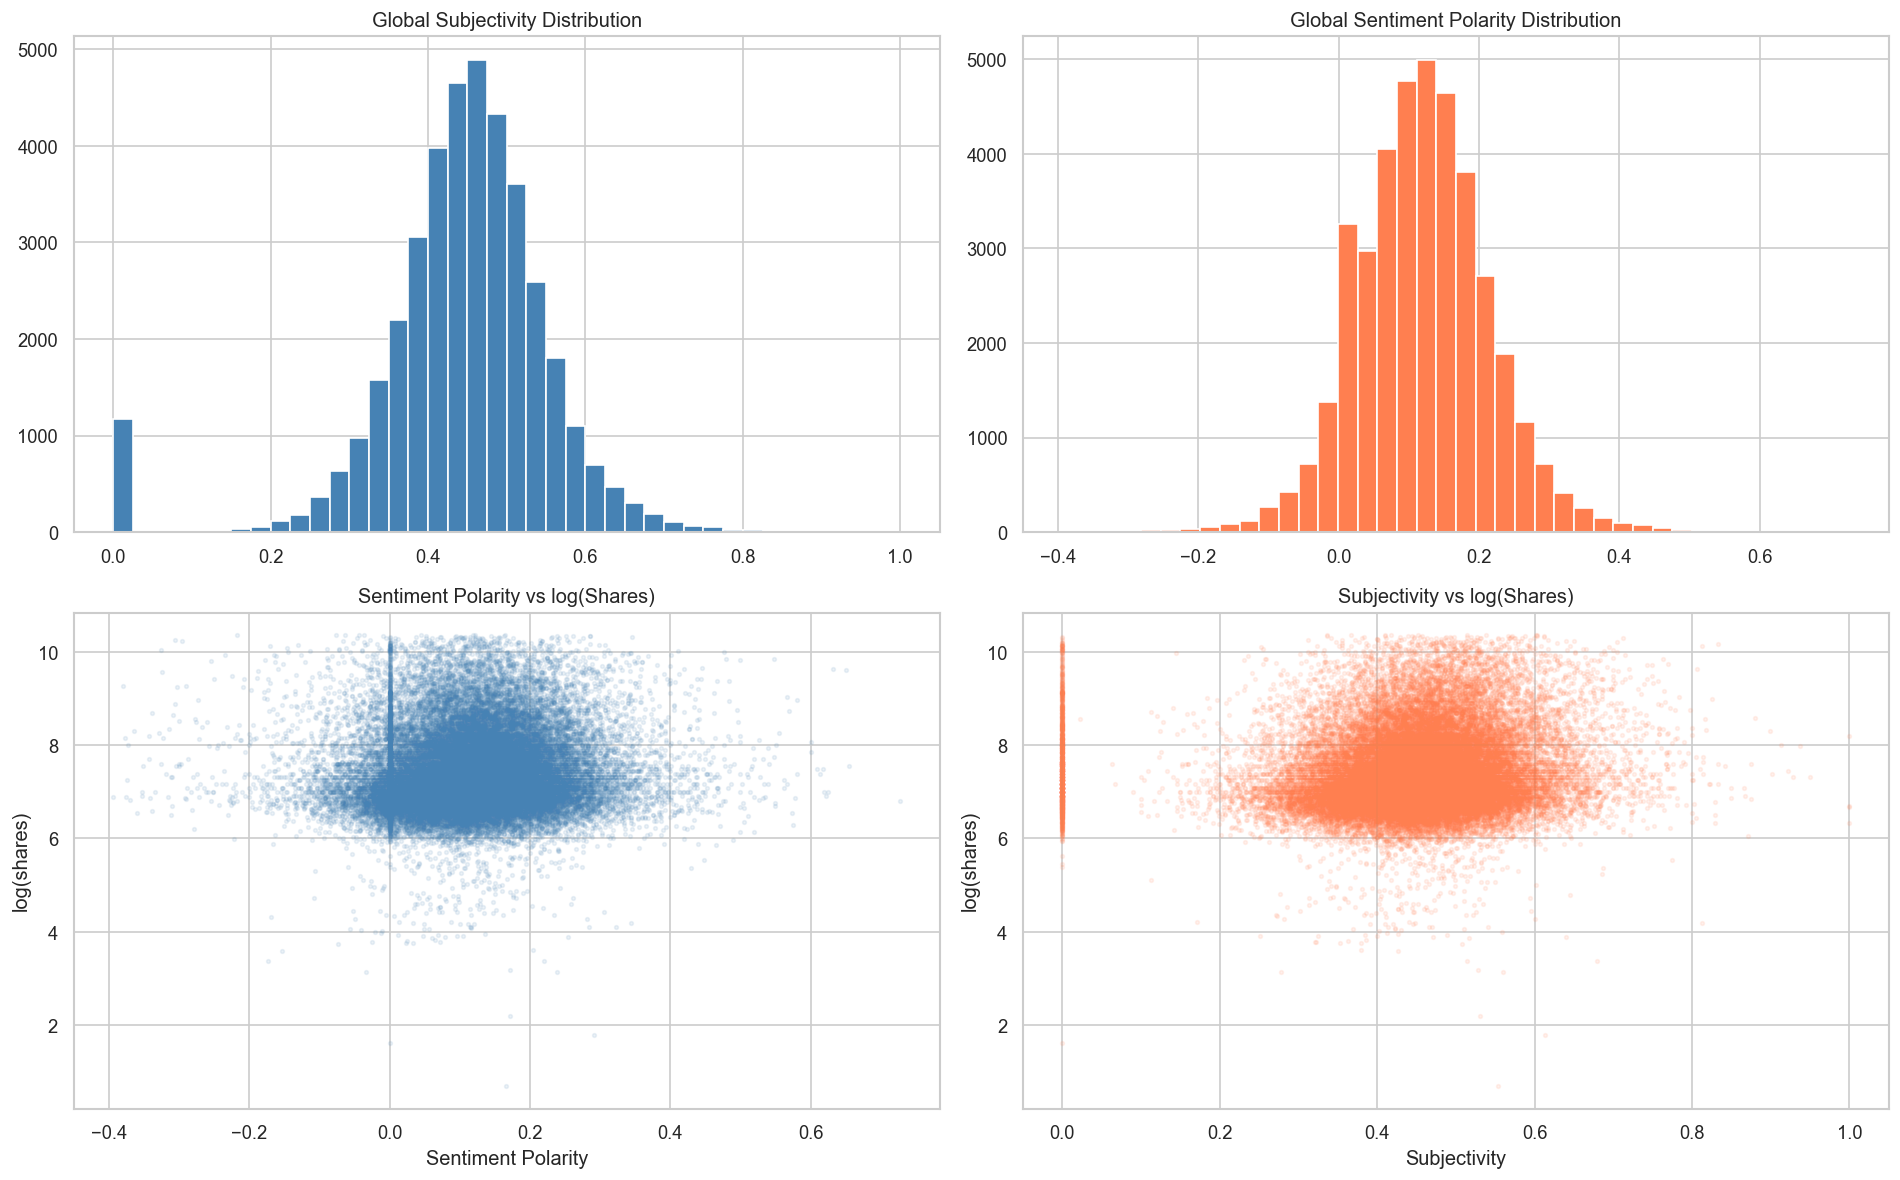

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


axes[0, 0].hist(df['global_subjectivity'], bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Global Subjectivity Distribution')


axes[0, 1].hist(df['global_sentiment_polarity'], bins=40, color='coral', edgecolor='white')
axes[0, 1].set_title('Global Sentiment Polarity Distribution')


axes[1, 0].scatter(df['global_sentiment_polarity'], df['log_shares'],
                   alpha=0.1, color='steelblue', s=5)
axes[1, 0].set_xlabel('Sentiment Polarity')
axes[1, 0].set_ylabel('log(shares)')
axes[1, 0].set_title('Sentiment Polarity vs log(Shares)')


axes[1, 1].scatter(df['global_subjectivity'], df['log_shares'],
                   alpha=0.1, color='coral', s=5)
axes[1, 1].set_xlabel('Subjectivity')
axes[1, 1].set_ylabel('log(shares)')
axes[1, 1].set_title('Subjectivity vs log(Shares)')

plt.tight_layout()
plt.savefig('figures/eda11_sentiment.png', bbox_inches='tight')
plt.show()

Pairplot (Top Features)

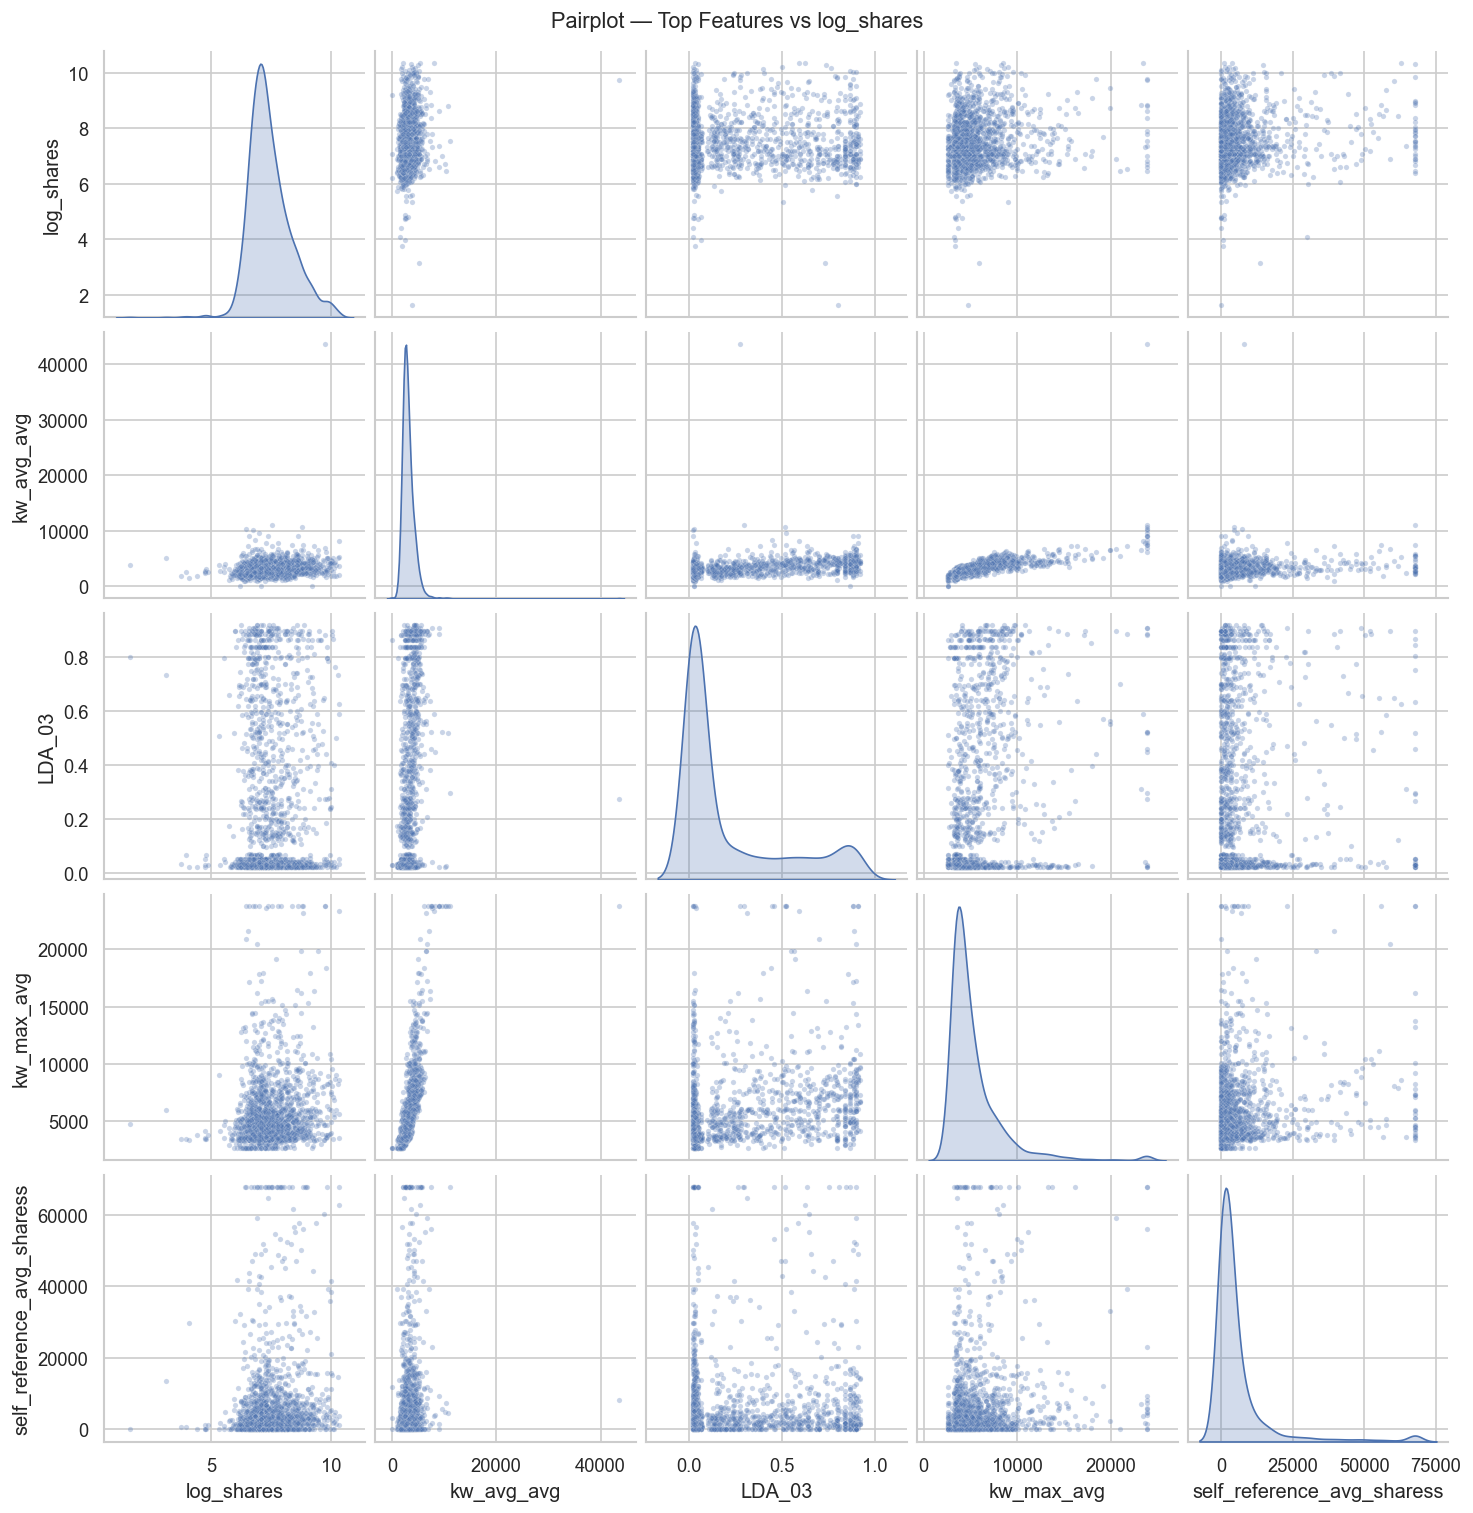

In [18]:
selected = ['log_shares', 'kw_avg_avg', 'LDA_03', 'kw_max_avg', 'self_reference_avg_sharess']
selected = [c for c in selected if c in df.columns]

sns.pairplot(df[selected].sample(2000, random_state=42), 
             diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot — Top Features vs log_shares', y=1.01, fontsize=13)
plt.savefig('figures/eda12_pairplot.png', bbox_inches='tight')
plt.show()

Density Plots

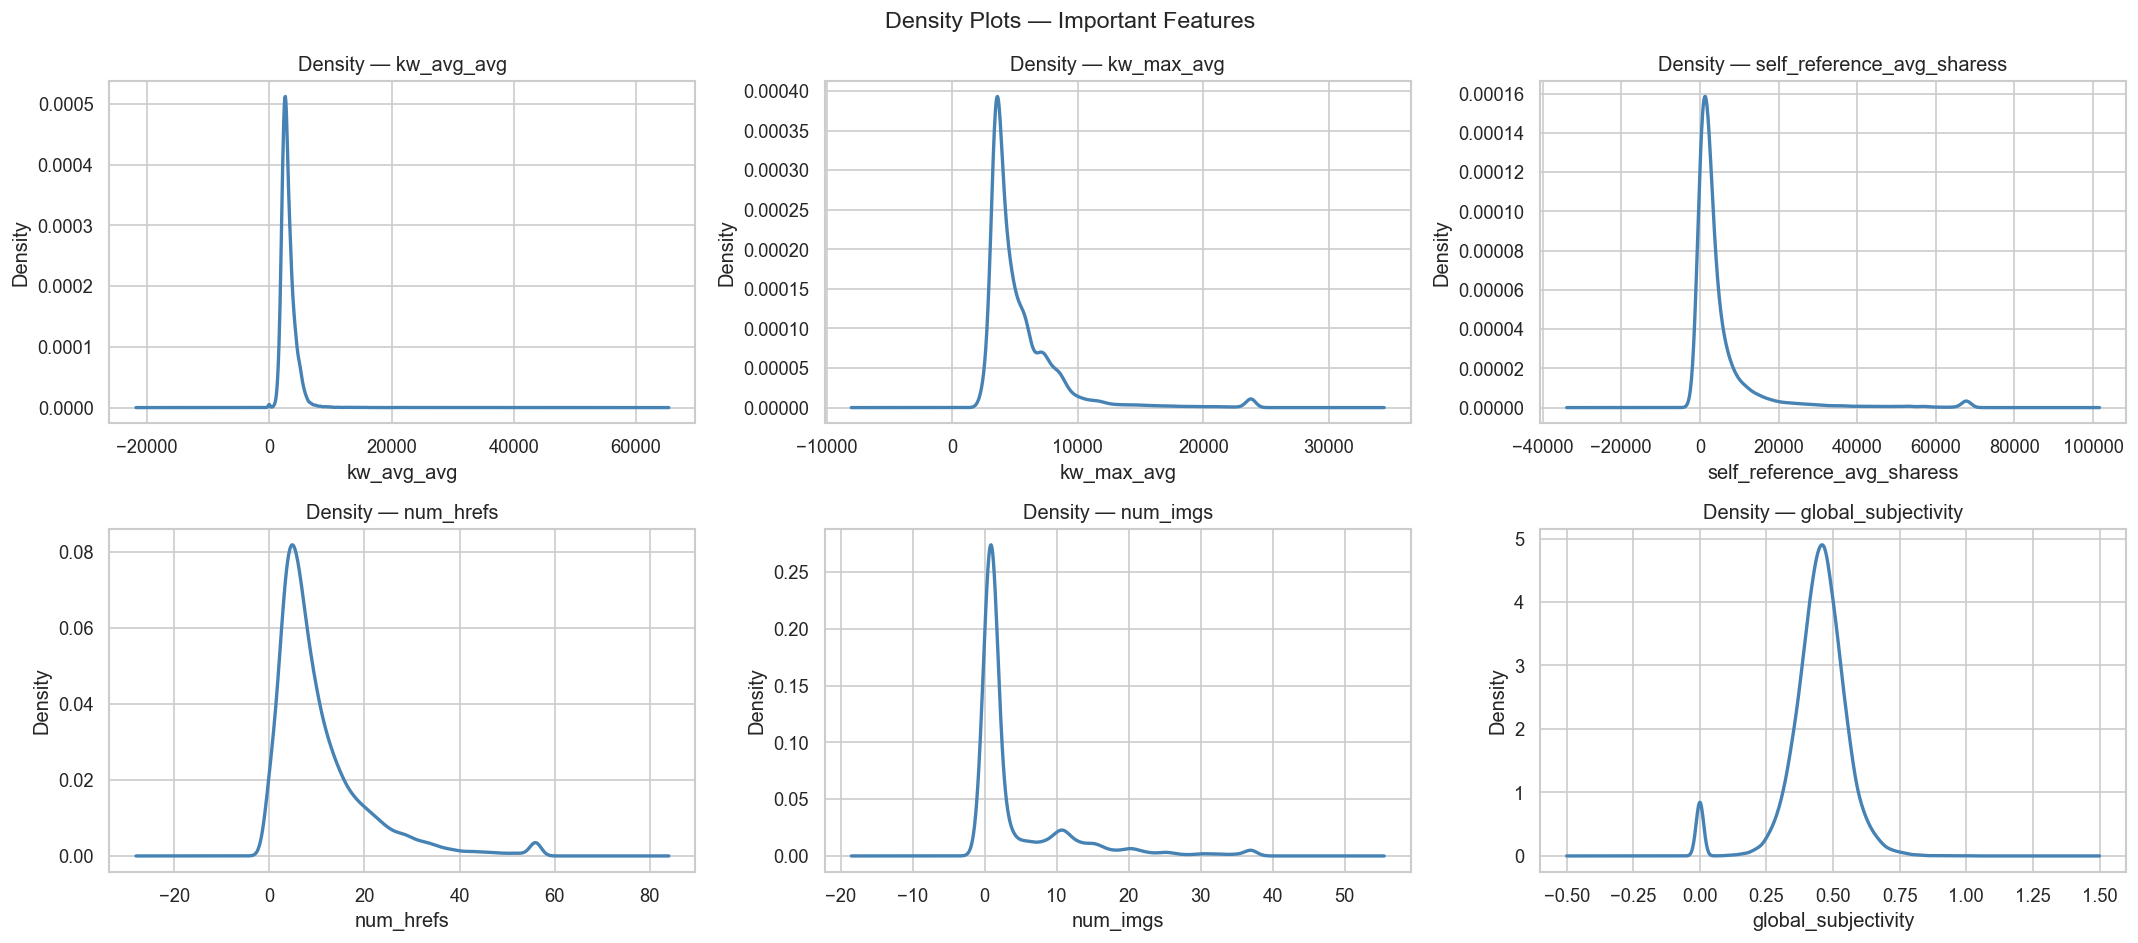

In [19]:
important_cols = ['kw_avg_avg', 'kw_max_avg', 'self_reference_avg_sharess',
                  'num_hrefs', 'num_imgs', 'global_subjectivity']
important_cols = [c for c in important_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(important_cols):
    df[col].plot(kind='density', ax=axes[i], color='steelblue', lw=2)
    axes[i].set_title(f'Density — {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Density Plots — Important Features', fontsize=14)
plt.tight_layout()
plt.savefig('figures/eda13_density_plots.png', bbox_inches='tight')
plt.show()

Weekend vs Weekday

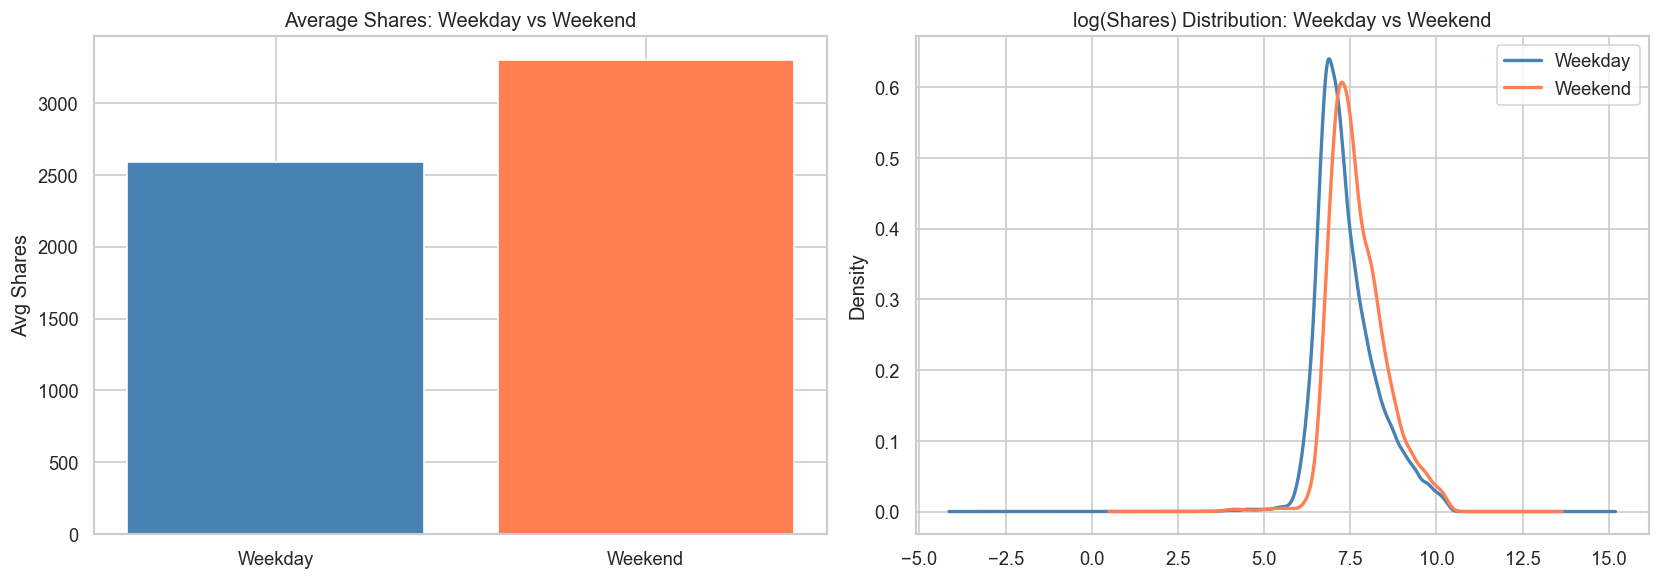

Weekday avg shares: 2,590
Weekend avg shares: 3,299


In [20]:
df['is_weekend'] = ((df['weekday_is_saturday'] + df['weekday_is_sunday']) > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


weekend_avg = df.groupby('is_weekend')['shares'].mean()
axes[0].bar(['Weekday', 'Weekend'], weekend_avg.values, color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Average Shares: Weekday vs Weekend')
axes[0].set_ylabel('Avg Shares')


df[df['is_weekend'] == 0]['log_shares'].plot(kind='density', ax=axes[1],
                                              color='steelblue', label='Weekday', lw=2)
df[df['is_weekend'] == 1]['log_shares'].plot(kind='density', ax=axes[1],
                                              color='coral', label='Weekend', lw=2)
axes[1].set_title('log(Shares) Distribution: Weekday vs Weekend')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/eda14_weekend_vs_weekday.png', bbox_inches='tight')
plt.show()

print(f"Weekday avg shares: {weekend_avg[0]:,.0f}")
print(f"Weekend avg shares: {weekend_avg[1]:,.0f}")

LDA Topic Analysis

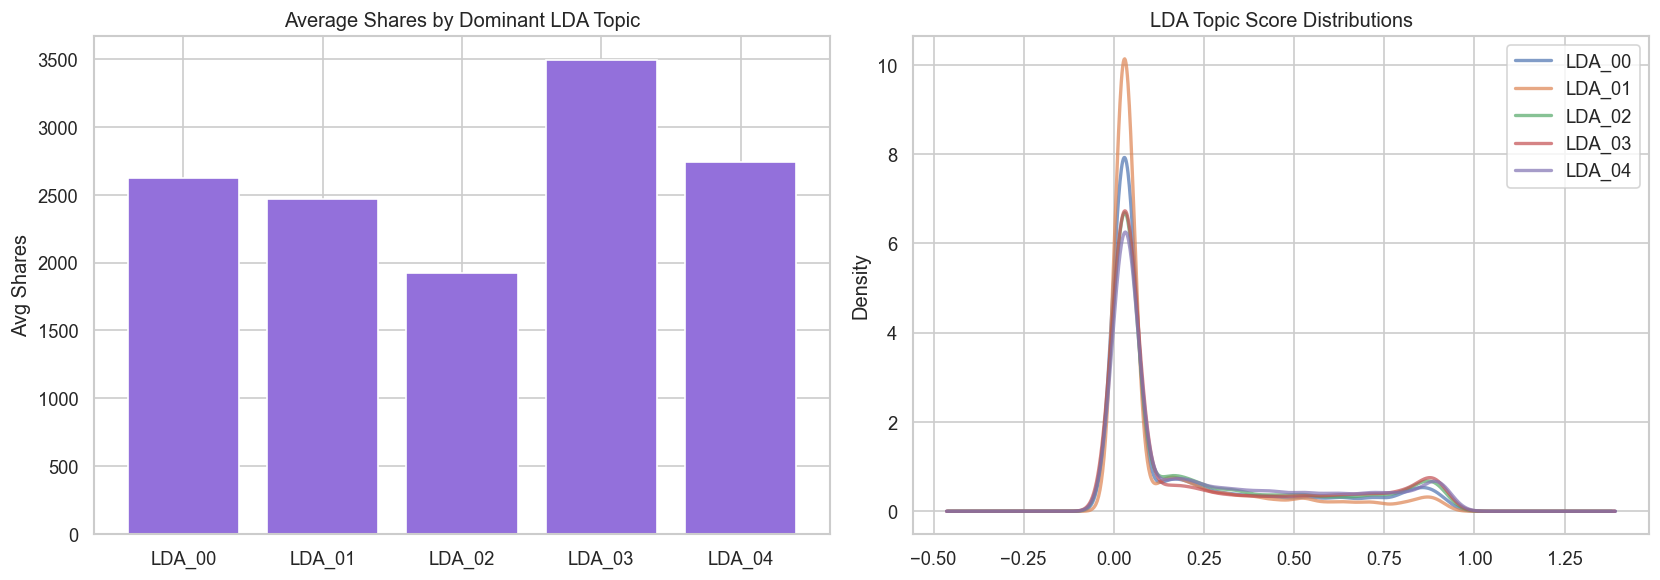

In [21]:
lda_cols = [c for c in df.columns if c.startswith('LDA_')]

lda_avg_shares = {}
for col in lda_cols:
   
    dominant_mask = df[lda_cols].idxmax(axis=1) == col
    lda_avg_shares[col] = df.loc[dominant_mask, 'shares'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(lda_avg_shares.keys(), lda_avg_shares.values(),
            color='mediumpurple', edgecolor='white')
axes[0].set_title('Average Shares by Dominant LDA Topic')
axes[0].set_ylabel('Avg Shares')


for col in lda_cols:
    df[col].plot(kind='density', ax=axes[1], label=col, lw=2, alpha=0.7)
axes[1].set_title('LDA Topic Score Distributions')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/eda15_lda_topics.png', bbox_inches='tight')
plt.show()

Popularity Distribution Analysis

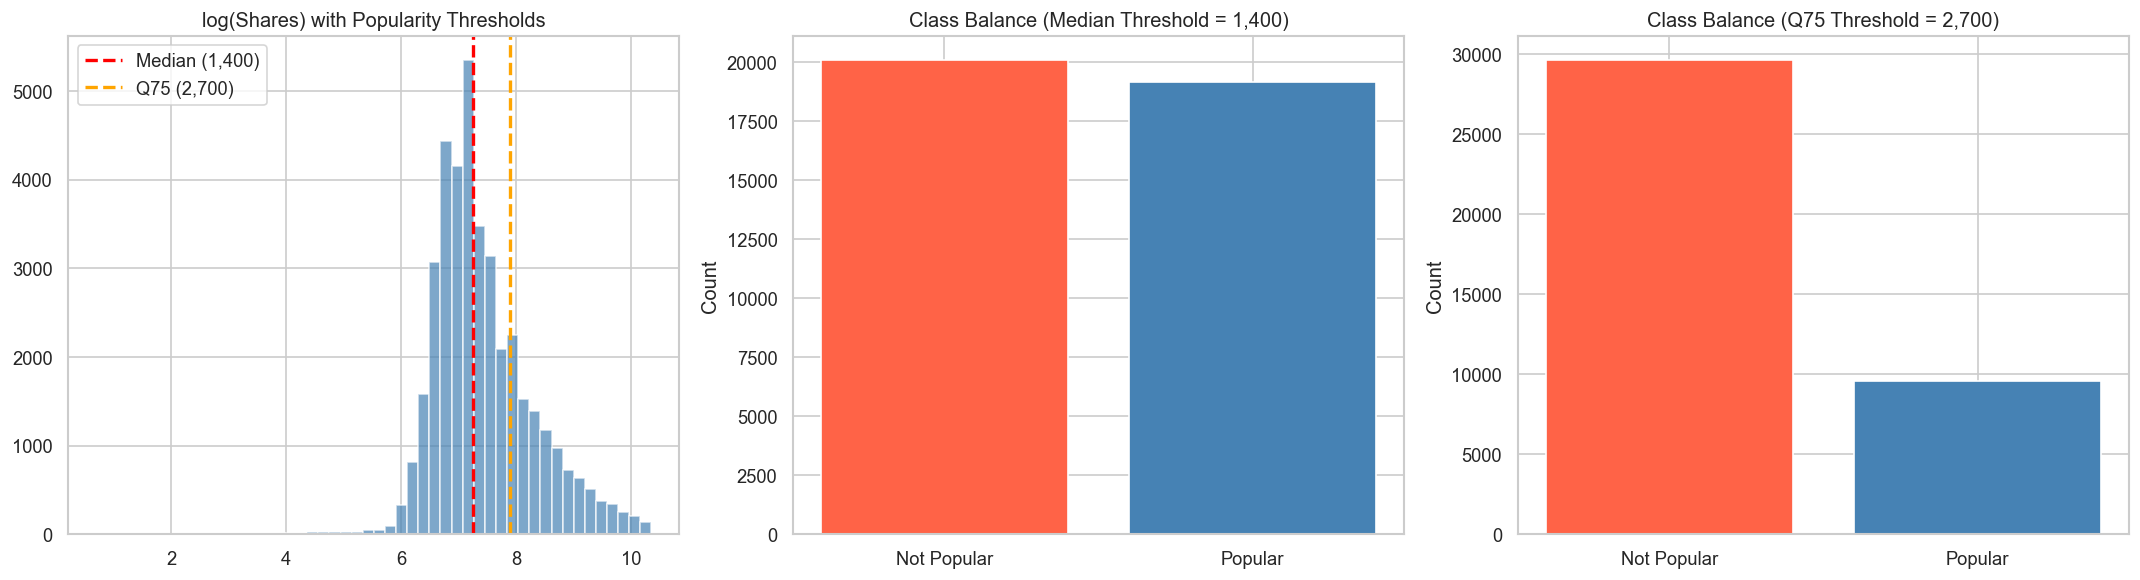

Median threshold: 1,400.0
Q75 threshold: 2,700.0

Median split — Popular: 48.8%
Q75 split — Popular: 24.4%


In [22]:

median_shares = df['shares'].median()
q75_shares = df['shares'].quantile(0.75)

df['popular_median'] = (df['shares'] > median_shares).astype(int)
df['popular_q75'] = (df['shares'] > q75_shares).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].hist(df['log_shares'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(np.log1p(median_shares), color='red', linestyle='--', lw=2, label=f'Median ({median_shares:,.0f})')
axes[0].axvline(np.log1p(q75_shares), color='orange', linestyle='--', lw=2, label=f'Q75 ({q75_shares:,.0f})')
axes[0].set_title('log(Shares) with Popularity Thresholds')
axes[0].legend()


axes[1].bar(['Not Popular', 'Popular'],
            df['popular_median'].value_counts().sort_index().values,
            color=['tomato', 'steelblue'], edgecolor='white')
axes[1].set_title(f'Class Balance (Median Threshold = {median_shares:,.0f})')
axes[1].set_ylabel('Count')


axes[2].bar(['Not Popular', 'Popular'],
            df['popular_q75'].value_counts().sort_index().values,
            color=['tomato', 'steelblue'], edgecolor='white')
axes[2].set_title(f'Class Balance (Q75 Threshold = {q75_shares:,.0f})')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('figures/eda16_popularity_distribution.png', bbox_inches='tight')
plt.show()

print(f"Median threshold: {median_shares:,}")
print(f"Q75 threshold: {q75_shares:,}")
print(f"\nMedian split — Popular: {df['popular_median'].mean()*100:.1f}%")
print(f"Q75 split — Popular: {df['popular_q75'].mean()*100:.1f}%")

EDA Summary

In [23]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"\n Dataset:")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")
print(f"   Memory: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")

print(f"\n Target Variable (shares):")
print(f"   Mean:     {df['shares'].mean():,.0f}")
print(f"   Median:   {df['shares'].median():,.0f}")
print(f"   Skewness: {df['shares'].skew():.2f}")
print(f"   log_shares skewness: {df['log_shares'].skew():.4f}")

print(f"\n Data Quality:")
print(f"   Missing values: {df.isnull().sum().sum()}")
print(f"   Duplicates: {df.duplicated().sum()}")

print(f"\n Top 5 Correlated Features with log_shares:")
top5 = df[num_cols + ['log_shares']].corr()['log_shares'].drop('log_shares').abs().sort_values(ascending=False).head(5)
for feat, corr in top5.items():
    print(f"   {feat}: {corr:.4f}")

print(f"\n  EDA Complete! All figures saved in 'figures/' folder")

EDA SUMMARY

 Dataset:
   Rows: 39,247
   Columns: 64
   Memory: 23.5 MB

 Target Variable (shares):
   Mean:     2,683
   Median:   1,400
   Skewness: 3.79
   log_shares skewness: 0.6857

 Data Quality:
   Missing values: 0
   Duplicates: 0

 Top 5 Correlated Features with log_shares:
   kw_avg_avg: 0.2095
   kw_max_avg: 0.1661
   LDA_02: 0.1647
   data_channel_is_world: 0.1539
   self_reference_avg_sharess: 0.1515

  EDA Complete! All figures saved in 'figures/' folder
